# FNE TUNING LLMS

Fine-tuning LLMs is a process where you take a pre-trained large language model (LLM) and train it further on a smaller, specific dataset.

This allows the model to adapt to a particular task or domain, improving its performance and generating more relevant outputs for that specific purpose. Think of it like specializing a general-purpose tool for a particular job.

## 1. Quantization

Conversion from higher memory format to a lower memory format.

- The weights and biases in the model will be stored in full precision/single precision (full 32 bits floating point numbers).
- Loading such a model costs a lot of hardware requirements.
- FP 16 bits is half precision.
- So we are making it into smaller model so we can use it for faster inferencing purposes.

### 1.1 How to perform Quantization?

1. Symmetric Quantization
- Symmetric Unsigned int8 Quantization

  **MIN MAX SCALER**
  
  Single precision : 1 Sign bit, 8 Exponent and 23 Mantissa

  Half precision : 1 Sign bit, 5 Exponent, 10 Mantissa

2. Asymmetric Quantization
- Asymmetric Unsigned int8 Quantization

## 2. Caliberation

Calibration refers to a process used in quantization. It involves determining the optimal scaling factors and zero points for quantizing the weights and activations of the model. This process helps to minimize the loss of information that occurs during the conversion from a higher-precision format (like 32-bit floating point) to a lower-precision format (like 8-bit integer). By carefully calibrating, you can ensure that the quantized model retains as much of its original accuracy as possible while benefiting from reduced memory usage and faster inference.

## 3. Modes of Quantization

### 3.1 Post Training Quantization (PTQ)

PTQ stands for Post Training Quantization. It's a quantization technique that happens after the model has been fully trained. You can think of it as a way to compress the model to make it more efficient for deployment without requiring further training.

### 3.2 Quantization Aware Training (QAT)

Quantization Aware Training (QAT). QAT is a technique where the model is trained with the knowledge that it will be quantized later. This helps the model learn to be more robust to the effects of quantization, often leading to better accuracy than PTQ.




## 4. LoRA - Low-Rank Adaptation

LoRA stands for Low-Rank Adaptation. It's a fine-tuning technique that is particularly useful for large language models. Instead of fine-tuning all of the model's parameters, LoRA injects small, trainable matrices into each layer of the pre-trained model. This significantly reduces the number of parameters that need to be trained, making fine-tuning much more efficient in terms of computational resources and time, while still achieving performance comparable to full fine-tuning.

### Full Parameter Fine Tuning [ Challenges ]

- Update all the midek weights (175B)
- Hardware resource constraint

### What does LoRA do?

- Instead of updating the weights, it tracks the changes in them.
- The tracked changes is formed by Model Decomposition based on the parameter called RANK.

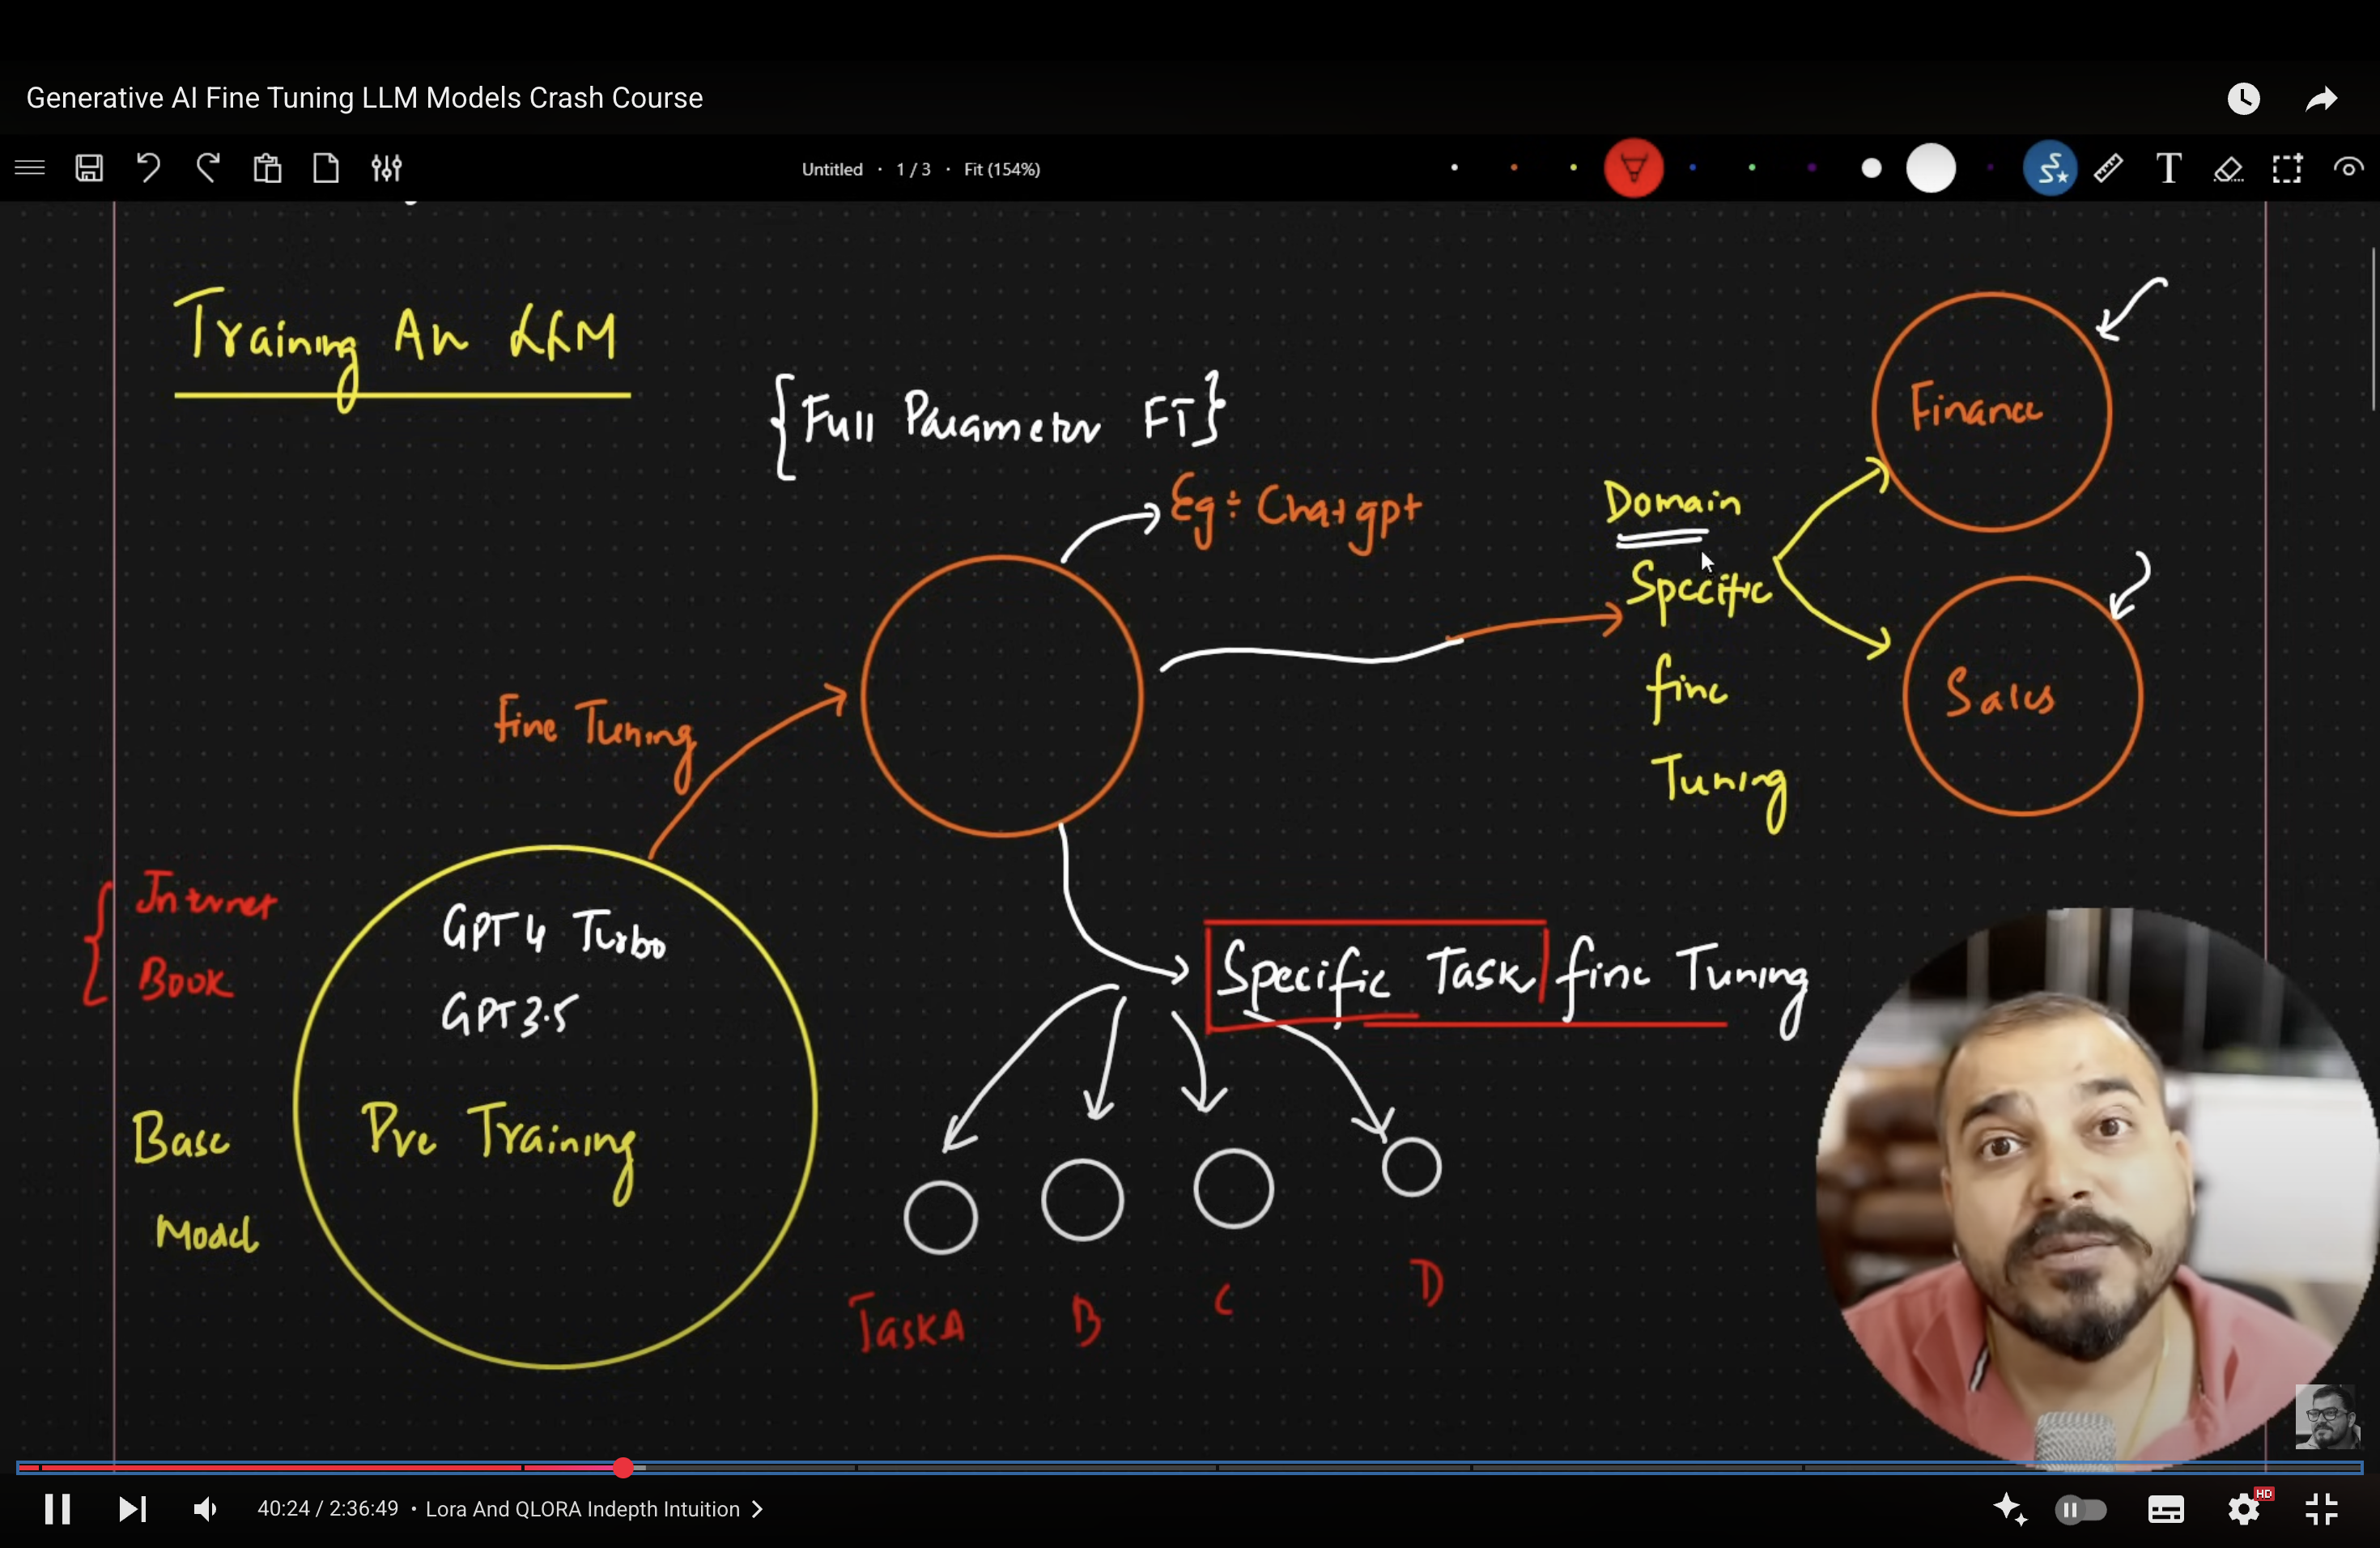

The number of trainable parameters increases with increase in the rank.

We should use bigger ranks when the model is gonna be doing complex tasks.

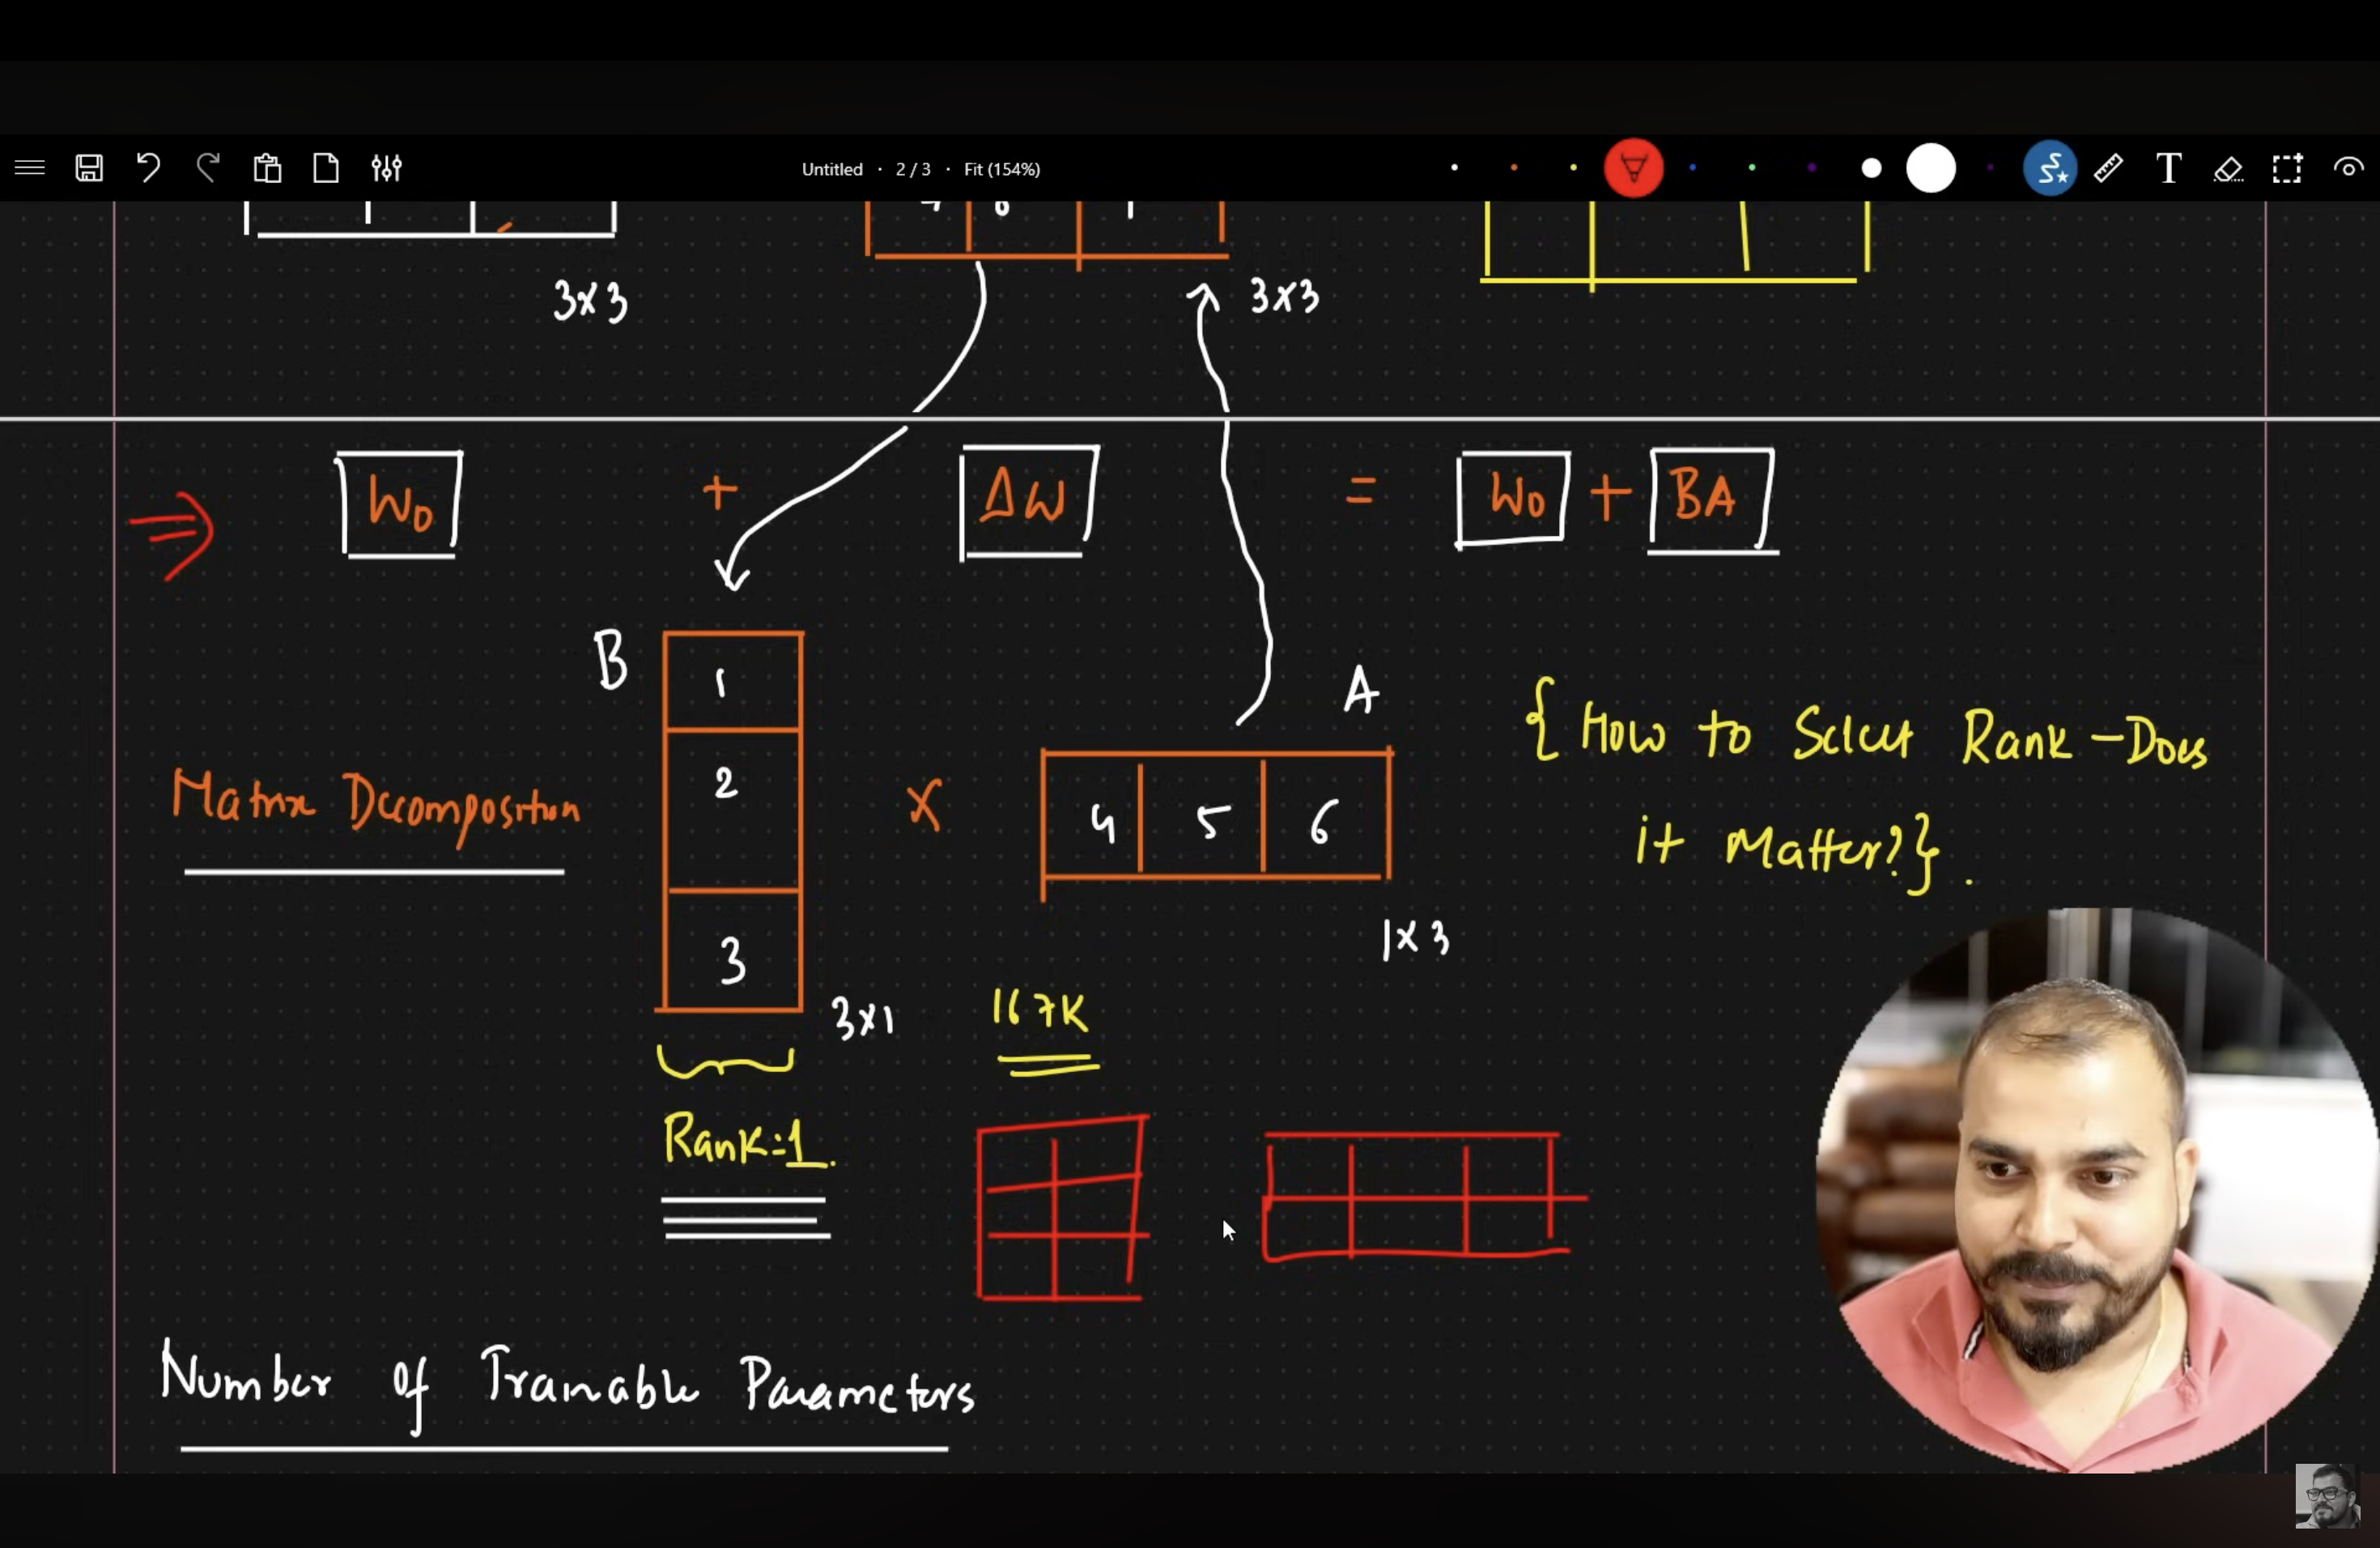

## 5. QLoRA - Quantized Low-Rank Adaptation

QLoRA stands for Quantized Low-Rank Adaptation. It's an optimization of LoRA that combines LoRA with quantization techniques. Essentially, QLoRA applies LoRA to a quantized version of the pre-trained model. This further reduces the memory footprint and computational cost of fine-tuning, making it possible to fine-tune even larger models on less hardware while maintaining performance.

It can also dequantize it back to the original size.

# FINE TUNING WITH LLAMA 2

## Install all the required packages



The packages being installed are commonly used for fine-tuning large language models efficiently. Here's a brief explanation of each:

- `accelerate`: This library from Hugging Face helps in easily running the same PyTorch code across different types of hardware (like multiple GPUs) without significant code changes. It's useful for speeding up training and fine-tuning of large models.

- `peft`: Also from Hugging Face, PEFT (Parameter-Efficient Fine-Tuning) is a library that provides implementations of various parameter-efficient fine-tuning techniques like LoRA. It allows you to fine-tune large models with significantly fewer trainable parameters, reducing computational costs.

- `bitsandbytes`: This library provides optimized implementations for operations involving quantized data types (like 8-bit integers). It's essential for techniques like QLoRA which use quantization to reduce memory usage and speed up computations.

- `transformers`: This is a widely used library from Hugging Face that provides access to a vast collection of pre-trained models, including various LLMs, and tools for working with them (like tokenizers, training utilities, etc.).

- `trl`: TRL (Transformer Reinforcement Learning) is a library that helps in applying reinforcement learning techniques to fine-tune transformer models, often used for tasks like aligning LLMs with human preferences.

These packages together provide the necessary tools and optimizations to efficiently fine-tune large language models using techniques like LoRA and QLoRA, which are discussed in the notebook.

In [3]:
!pip install transformers accelerate peft bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 33.0 MB/s eta 0:00:00


## Import All the Required Libraries

In [4]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer

## Prompt template for Llama 2 chat model

System Prompt (optional) to guide the model

User prompt (required) to give the instruction

Model Answer (required)

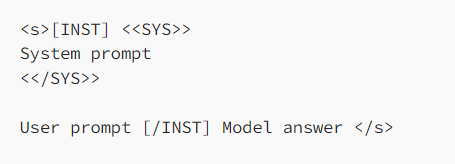

## Reformat the dataset according to template

- Orignal Dataset: https://huggingface.co/datasets/timdettmers/openassistant-guanaco

- Reformat Dataset following the Llama 2 template with 1k sample: https://huggingface.co/datasets/mlabonne/guanaco-llama2-1k

- Complete Reformat Dataset following the Llama 2 template: https://huggingface.co/datasets/mlabonne/guanaco-llama2

To know how this dataset was created, you can check this notebook.  

https://colab.research.google.com/drive/1Ad7a9zMmkxuXTOh1Z7-rNSICA4dybpM2?usp=sharing

**Note**: You don’t need to follow a specific prompt template if you’re using the base Llama 2 model instead of the chat version.

## How to Fine-tune it?

- Free Google Colab offers a 15GB Graphics Card (Limited Resources --> Barely enough to store Llama 2–7b’s weights)
- To drastically reduce the VRAM usage, we must fine-tune the model in 4-bit precision, which is why we’ll use QLoRA here.
- We also need to consider the overhead due to optimizer states, gradients, and forward activations
- Full fine-tuning is not possible here: we need parameter-efficient fine-tuning (PEFT) techniques like LoRA or QLoRA.

1. Load a llama-2-7b-chat-hf model (chat model)
2. Train it on the mlabonne/guanaco-llama2-1k (1,000 samples), which will produce our fine-tuned model Llama-2-7b-chat-finetune

QLoRA will use a rank of 64 with a scaling parameter of 16. We’ll load the Llama 2 model directly in 4-bit precision using the NF4 type and train it for one epoch

In [5]:
# The model that you want to train from the Hugging Face hub
model_name = "NousResearch/Llama-2-7b-chat-hf"

# The instruction dataset to use
dataset_name = "mlabonne/guanaco-llama2-1k"

# Fine-tuned model name
new_model = "Llama-2-7b-chat-finetune"

################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 64

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "./results"

# Number of training epochs
num_train_epochs = 1

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = False

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "cosine"

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 0

# Log every X updates steps
logging_steps = 25

################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = None

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

## Load everything and start the fine-tuning process

1. First of all, we want to load the dataset we defined. Here, our dataset is already preprocessed but, usually, this is where you would reformat the prompt, filter out bad text, combine multiple datasets, etc.


2. Then, we’re configuring bitsandbytes for 4-bit quantization.


3. Next, we're loading the Llama 2 model in 4-bit precision on a GPU with the corresponding tokenizer.


4. Finally, we're loading configurations for QLoRA, regular training parameters, and passing everything to the SFTTrainer. The training can finally start!

In [6]:
# Load dataset (you can process it here)
dataset = load_dataset(dataset_name, split="train")

# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Fix weird overflow issue with fp16 training

# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

# Set training parameters
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard"
)

# Set supervised fine-tuning parameters
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    tokenizer=tokenizer,
    args=training_arguments,
    packing=packing,
)

# Train model
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-9ad84bb9cf65a4(…):   0%|          | 0.00/967k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
# Save trained model
trainer.model.save_pretrained(new_model)

## Check the plots on tensorboard, as follows

In [ ]:
%load_ext tensorboard
%tensorboard --logdir results/runs

## Use the text generation pipeline to ask questions like “What is a large language model?”

 Note: that I’m formatting the input to match Llama 2 prompt template.

In [ ]:
# Ignore warnings
logging.set_verbosity(logging.CRITICAL)

# Run text generation pipeline with our next model
prompt = "What is a large language model?"
pipe = pipeline(task="text-generation", model=model, tokenizer=tokenizer, max_length=200)
result = pipe(f"<s>[INST] {prompt} [/INST]")
print(result[0]['generated_text'])

In [ ]:
# Empty VRAM
del model
del pipe
del trainer
import gc
gc.collect()
gc.collect()

You can train a Llama 2 model on the entire dataset using [mlabonne/guanaco-llama2](https://huggingface.co/datasets/mlabonne/guanaco-llama2)

#**Step 7: Store New Llama2 Model (Llama-2-7b-chat-finetune)**

How can we store our new Llama-2-7b-chat-finetune model now? We need to merge the weights from LoRA with the base model. Unfortunately, as far as I know, there is no straightforward way to do it: we need to reload the base model in FP16 precision and use the peft library to merge everything.

In [ ]:
# Reload model in FP16 and merge it with LoRA weights
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map=device_map,
)
model = PeftModel.from_pretrained(base_model, new_model)
model = model.merge_and_unload()

# Reload tokenizer to save it
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

#**Step 8: Push Model to Hugging Face Hub**

Our weights are merged and we reloaded the tokenizer. We can now push everything to the Hugging Face Hub to save our model.

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!huggingface-cli login

model.push_to_hub("entbappy/Llama-2-7b-chat-finetune", check_pr=True)

tokenizer.push_to_hub("entbappy/Llama-2-7b-chat-finetune",check_pr=True)


You can now use this model for inference by loading it like any other Llama 2 model from the Hub.